# Model YOLO with no prompt

## Chargement des libraries

In [1]:
import supervision as sv
import cv2
import os
import yaml
import random
import sys
import gc
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt

from pathlib import Path
from PIL import Image
from ultralytics import YOLO
from shapely import Polygon
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.model_selection import train_test_split

sys.path.append(str(Path.cwd().parent)) # Ajoute le dossier parent au chemin de recherche de Python

from utils.models_config import metrics_by_class
from utils.stats_fct import plot_segmentation_comparison

### Reproductibilité du code

In [2]:
# Seed global pour la reproductibilité
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# Déterminisme complet des opérations cuDNN (au prix d'un léger ralentissement)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

torch.cuda.is_available()

True

### Choix des données

In [3]:
DATASET_NAME = "3classes"  # "3classes" ou "2classses" ou "oeufs"

### Choix du type de modèle

In [4]:
MODEL_TYPE = "semantique"  # "semantique" ou "instance"

### Echantillonnage stratifié train/val - test

In [6]:
# ------- 1. Importation du Data Frame avec les metadata --------
metadata = pd.read_excel("../utils/correspondance_echo_final.xlsx", dtype={"annee" : str, "image_id": str, "new_name_file": str})

# -------- 2. Chemin des images --------
DATASET_CONFIG = {
    "3classes": {"images": "../data/YOLO/images", "classes" : ["Cavite", "Gonade", "Intestin"]},
    "oeufs": {"images": "../data/YOLO/oeufs", "classes" : ["Oeuf"]},
}
images_path = Path(DATASET_CONFIG[DATASET_NAME]["images"])

# -------- 3. Extraire les catégories pour chaque image --------
categories_all = []
for path in os.listdir(images_path):
    id_image = path.split("_")[0]
    
    matches = metadata.loc[metadata["image_id"] == id_image, "categorie"]

    if not matches.empty:
        # On prend la première valeur trouvée si des doublons existent
        cat = matches.values[0]
        categories_all.append(cat)
    else:
        # Si l'id_image n'existe pas du tout dans le fichier
        print(f"Image {id_image} introuvable dans les métadonnées.")
        categories_all.append(None)

# ----- 4. Séparation stratifiée par groupe : 85% Train/val et 15% Test -----
# On utilise 6 splits pour simuler un ratio 83/17 (proche de 85/15)
kf = StratifiedGroupKFold(n_splits=6, random_state=42, shuffle=True)
X = np.array(os.listdir(images_path), dtype=object) # Les images
y = np.array(categories_all) # Les classes
groups = np.array([path.split("_")[2] for path in os.listdir(images_path)]) # L'ID du poisson pour chaque image

for cv_idx, test_idx in kf.split(X, y, groups):
    cv_paths, test_paths = X[cv_idx], X[test_idx]
    cv_categories, test_categories = y[cv_idx], y[test_idx]
    groups_train, groups_test = groups[cv_idx], groups[test_idx]
    break # On ne garde que le premier split


print(f"Nombre total d'images valides : {len(os.listdir(images_path))}")
print(f"Échantillons train/val        : {len(cv_paths)}")
print(f"Échantillons de test          : {len(test_paths)}")

# Récupère le chemin en entier
cv_images = ['/home/ldepiero/Stage-GonAIde-2026/Debut/data/YOLO/images/' + path for path in cv_paths]

Nombre total d'images valides : 86
Échantillons train/val        : 70
Échantillons de test          : 16


In [7]:
test_paths

array(['0004592_12.15.09_356430_2019.jpg', '0004594_12.15.27_356430_2019.jpg', '0004593_12.15.19_356430_2019.jpg', '0004595_12.15.35_356430_2019.jpg', '0004679_12.34.50_356970_2019.jpg', '0004680_12.35.03_356970_2019.jpg', '0004681_12.35.13_356970_2019.jpg', '0006932_10.07.22_426711_2024.jpg',
       '0006933_10.07.40_426711_2024.jpg', '0006935_10.08.14_426711_2024.jpg', '0006934_10.07.55_426711_2024.jpg', '0007121_10.00.52_427202_2024.jpg', '0007131_10.25.42_427237_2024.jpg', '0007122_10.01.00_427202_2024.jpg', '0007133_10.25.56_427237_2024.jpg', '0007132_10.25.49_427237_2024.jpg'], dtype=object)

### Hyperparamètres

In [ ]:
# ------- 1. Paramètres du yaml --------
nc = len(DATASET_CONFIG[DATASET_NAME]["classes"])
names = DATASET_CONFIG[DATASET_NAME]["classes"]
names_mapping = {i: name for i, name in enumerate(names)}
label_mapping = {i: i for i in range(nc)}
if DATASET_NAME == "3classes":
    label_mapping[3] = "ignore_label"
k_folds = 5

# ------ 2. Découpage k-folds pour la cross validation --------
kf = StratifiedKFold(n_splits=k_folds, shuffle=True, random_state=42)

# ------ 3. Initialisation --------
results_list = []
val_paths_list = []

IMAGE_SIZE = 512

## Entrainement et validation du modèle

In [10]:
for fold, (train_index, val_index) in enumerate(kf.split(cv_images, cv_categories, groups_train)):
    print(f"\n{'='*30}\nLancement du Fold {fold + 1}/{k_folds}\n{'='*30}")

    # Séparer les chemins
    train_paths = [cv_images[i] for i in train_index]
    val_paths = [cv_images[i] for i in val_index]
    
    # Créer les fichiers .txt contenant les chemins
    train_txt = f'folds/train_fold_{fold}.txt'
    val_txt = f'folds/val_fold_{fold}.txt'

    with open(train_txt, 'w') as f:
        f.write('\n'.join(train_paths))
    with open(val_txt, 'w') as f:
        f.write('\n'.join(val_paths))
        
    # Créer le fichier .yaml
    yaml_data = {
        'train': train_txt,
        'val': val_txt,
        'nc': nc,
        'names': names_mapping,
        'label_mapping': label_mapping
    }

    yaml_file = f'data_fold_{fold}.yaml'
    with open(yaml_file, 'w') as f:
        yaml.dump(yaml_data, f, default_flow_style=False)
        
    # -------- Entrainement du modèle --------
    # Initialisation
    if MODEL_TYPE == "instance":
        model = YOLO("yolo26l-seg.pt")
    elif MODEL_TYPE == "semantique":
        model = YOLO("yolo26l-sem.pt")
    
    # Entraînement
    model.train(data=yaml_file, epochs=10, patience = 10, lr0 = 0.001,
            hsv_h=0.0,
            hsv_s=0.0,
            hsv_v=0.4, #0.4
            degrees=20, #20
            translate=0.2, #0.2
            scale=0.2, #0.2
            fliplr=0.0,
            mosaic=0.0,
            erasing=0.0,
            auto_augment=None,
            box=15.0,
            cls=0.3,
            imgsz=IMAGE_SIZE)
    
    # -------- Validation et prédiction du modèle --------
    print(f"\nÉvaluation du Fold {fold + 1}...")
    results = model.val(data=yaml_file)
    preds = model.predict(source=val_paths, retina_masks=True, conf=0.2, verbose=False)
    
    results_list.append(preds)    
    val_paths_list.append(val_paths)

    # ---------------------------------------------------------
    # Nettoyage de la mémoire GPU pour éviter l'erreur NVML
    # ---------------------------------------------------------
    del model
    del results
    del preds
    gc.collect()
    torch.cuda.empty_cache()

print("\nValidation croisée terminée avec succès !")


Lancement du Fold 1/5
New https://pypi.org/project/ultralytics/8.4.121 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.70 🚀 Python-3.14.2 torch-2.12.0+cu130 CUDA:0 (NVIDIA RTX 2000 Ada Generation, 15947MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=None, batch=16, bgr=0.0, box=15.0, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.3, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data_fold_0.yaml, degrees=20, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.0, exist_ok=False, fliplr=0.0, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.0, hsv_s=0.0, hsv_v=0.4, imgsz=512, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26l-sem.pt, momentum=0.937, mosaic=

## Résultats validation

In [11]:
# ----- 1. Choix du fold et de l'image à visualiser -----
VIS_FOLD = 1  # Numéro du fold, entre 1 et k_folds
VIS_INDEX = 1  # Index de l'image dans le jeu de validation du fold (0 à len(val_paths)-1)

print(f"Nombre de folds: {len(results_list)}")
print(f"Nombre d'images dans le fold {VIS_FOLD}: {len(val_paths_list[VIS_FOLD - 1])}")

# ----- 2. Vérification des indices ----
if not 1 <= VIS_FOLD <= k_folds:
    raise ValueError(f"VIS_FOLD doit être compris entre 1 et {k_folds}.")

if not 0 <= VIS_INDEX < len(val_paths_list[VIS_FOLD - 1]):
    raise IndexError(
        f"VIS_INDEX doit être compris entre 0 et {len(val_paths_list[VIS_FOLD - 1]) - 1} "
        f"pour le fold {VIS_FOLD}."
    )

Nombre de folds: 5
Nombre d'images dans le fold 1: 14


Image : 0004598_12.17.20_356434_2019.jpg


,dice,iou,precision,recall,diff_surface (cm²)
classe,,,,,
Cavite,0.3300,0.1976,0.6417,0.2221,1.6025
Gonade,0.7032,0.5422,0.5557,0.9573,0.8688
Intestin,0.0000,0.0000,0.0000,0.0000,0.2404
Global,0.4976,0.3312,0.5807,0.4354,2.7117


480 640


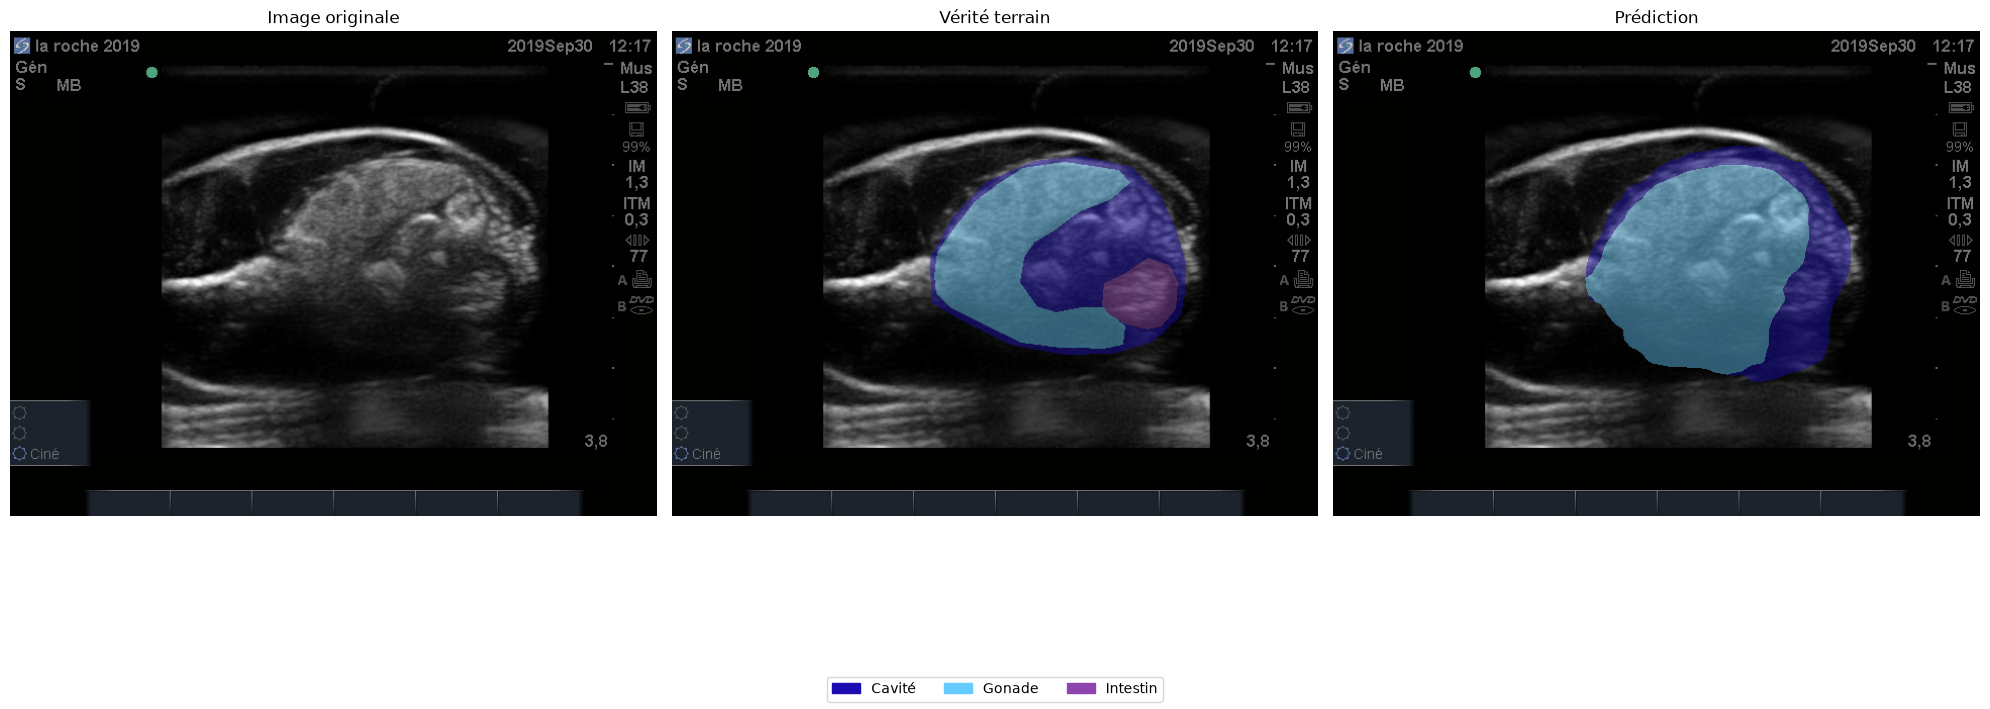

(<Figure size 2000x800 with 3 Axes>,
 array([<Axes: title={'center': 'Image originale'}>, <Axes: title={'center': 'Vérité terrain'}>, <Axes: title={'center': 'Prédiction'}>], dtype=object))

In [12]:
# Affichage des figures dans le notebook
%matplotlib inline

# Chemin du masque correspondant à l'image
val_path = val_paths_list[VIS_FOLD - 1][VIS_INDEX]
mask_path = val_path.replace('/images/', '/labels/').replace('.jpg', '.txt')

# ----- 1. Chargement de l'image -----
img_bgr = cv2.imread(val_path)
H_orig, W_orig, _ = img_bgr.shape

img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

# Conversion de l'image en tenseur
image_tensor = torch.tensor(img_rgb).permute(2, 0, 1).float() / 255.0
_, H, W = image_tensor.shape

# ----- 3. Récupération du masque prédit -----
preds = results_list[VIS_FOLD - 1][VIS_INDEX]

# Si segmentation sémantique
if MODEL_TYPE == "semantique":
    p_mask = preds.semantic_mask.data.cpu().numpy()
    # Ajoute une dimension pour les classes si nécessaire
    if p_mask.ndim == 2: 
        p_mask = np.array([p_mask == class_id for class_id in range(nc)])

# Si segmentation d'instances
elif MODEL_TYPE == "instance":
    # On initialise un masque vide aux dimensions exactes de l'image originale
    p_mask = np.zeros((nc, H_orig, W_orig), dtype=np.uint8)

    if hasattr(preds, 'masks') and preds.masks is not None:
        # On parcourt chaque instance détectée
        for i, cls_id in enumerate(preds.boxes.cls.cpu().numpy().astype(int)):
            if cls_id < nc:
                # .xy contient les coordonnées des polygones corrigées du padding
                pts = preds.masks.xy[i] 
                
                if len(pts) >= 3: # Un polygone nécessite au moins 3 points
                    # Conversion en entiers pour OpenCV
                    pts_int = np.round(pts).astype(np.int32)
                    
                    # On dessine le polygone sur le canal de la classe correspondante
                    cv2.fillPoly(p_mask[cls_id], [pts_int], 1)

# ----- 4. Récupération du masque réel -----
t_mask_np = np.zeros((nc, H, W), dtype=np.uint8)
if os.path.exists(mask_path):
    with open(mask_path, 'r') as f:
        for line in f.readlines():
            parts = line.strip().split()
            if len(parts) >= 5: # ID de classe + au moins 3 points (x, y) pour faire un polygone
                cls_id = int(parts[0])
                if cls_id < nc:
                    # Les coordonnées YOLO sont normalisées [0, 1], on les reshape en paires (x, y)
                    pts = np.array(parts[1:], dtype=float).reshape(-1, 2)
                    
                    # Dénormalisation vers la taille réelle de l'image
                    pts[:, 0] *= W_orig  # Coordonnées X
                    pts[:, 1] *= H_orig  # Coordonnées Y
                    pts = np.round(pts).astype(np.int32)
                    
                    # Remplissage du polygone avec des 1 sur la bonne classe
                    cv2.fillPoly(t_mask_np[cls_id], [pts], 1)
else:
    print(f"Attention : Aucun label trouvé à {mask_path}, un masque vide sera utilisé.")


# ----- 5. Formatage des tenseurs -----
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# metrics_by_class attend des tenseurs booléens de forme [B, C, H, W] : ajoute une dimension "Batch" (B=1) avec unsqueeze(0)
true_tensor = torch.from_numpy(t_mask_np).unsqueeze(0).to(device=device, dtype=torch.bool)
preds_tensor = torch.from_numpy(p_mask).unsqueeze(0).to(device=device) > 0.5 

# ----- 6. Récupération de l'échelle ------
if DATASET_NAME == "oeufs":
    scale = 1.0
else:
    file_name = os.path.basename(val_path)
    scale_rows = metadata.loc[metadata["image_id"] == file_name.split("_")[0], "echelle"]
    if scale_rows.empty:
        raise ValueError(f"Échelle introuvable pour {file_name}")
    scale = float(scale_rows.iloc[0])

scale_tensor = torch.tensor([[scale]], device=device, dtype=torch.float32)

# ------ 7. Calcul des métriques -------
intersection, union, iou, dice, precision, recall, diff_surface = metrics_by_class(
    true=true_tensor, 
    preds=preds_tensor, 
    echelle=scale_tensor, 
    dataset_name=DATASET_NAME
)

# Correction du cas où le masque prédit et le masque réel sont vides
true_area = true_tensor.sum(dim=(2, 3)).float()
pred_area = preds_tensor.sum(dim=(2, 3)).float()
empty = (true_area + pred_area) == 0
for metric in (iou, dice, precision, recall):
    metric[empty] = 1.0

# ----- 8. Affichage des métriques -----
print(f"Image : {os.path.basename(val_path)}")

metric_rows = []
for class_idx, class_name in preds.names.items():
    if class_idx < nc:  # S'assure que l'index de classe est valide
        metric_rows.append({
            "classe": class_name,
            "dice": dice[0, class_idx].item(),
            "iou": iou[0, class_idx].item(),
            "precision": precision[0, class_idx].item(),
            "recall": recall[0, class_idx].item(),
            "diff_surface": diff_surface[0, class_idx].item(),
        })

intersection_global = intersection.sum()
union_global = union.sum()
true_global = true_area.sum()
pred_global = pred_area.sum()
metric_rows.append({
    "classe": "Global",
    "dice": (2 * intersection_global / (true_global + pred_global)).item() if true_global + pred_global > 0 else 1.0,
    "iou": (intersection_global / union_global).item() if union_global > 0 else 1.0,
    "precision": (intersection_global / pred_global).item() if pred_global > 0 else float(true_global == 0),
    "recall": (intersection_global / true_global).item() if true_global > 0 else float(pred_global == 0),
    "diff_surface": diff_surface.sum().item(),
})

metrics_table = pd.DataFrame(metric_rows).set_index('classe')
surface_unit = "pixels" if DATASET_NAME == "oeufs" else "cm²"
metrics_table = metrics_table.rename(columns={"diff_surface": f"diff_surface ({surface_unit})"})
display(metrics_table.style.format(precision=4))

# ------ 9. Affichage de l'image, du masque vrai et de la prédiction -------
plot_segmentation_comparison(
    image= image_tensor,
    mask_true = torch.tensor(t_mask_np),
    mask_pred=torch.tensor(p_mask),
    is_eggs=DATASET_NAME == "oeufs",
    alpha=0.45
)

### Sauvegarde des IoU de validation

In [16]:
import pickle
with open('fold_histories_data_aug_YOLO_test.pkl', 'wb') as fp:
    pickle.dump(folds_histories, fp)

## Résultats du modèle final sur l'échantillon test

### Chargement du modèle

In [24]:
# Relancer le modèle au choix avec les poids de la dernière session d'entraînement
model = YOLO("runs/segment/train_data_augmentation/weights/best.pt")
results = model.val(data="data_3_classes.yaml", conf=0.2, save=False)

Ultralytics 8.4.70 🚀 Python-3.14.4 torch-2.12.0+cu130 CUDA:0 (NVIDIA RTX A5000, 24114MiB)
YOLO26l-seg summary (fused): 207 layers, 27,906,069 parameters, 0 gradients, 139.4 GFLOPs



FileNotFoundError: Dataset 'data_3_classes.yaml' images not found, missing path '/home/ldepiero/Debut/YOLO26/data/YOLO/images/test'
Note dataset download directory is '/home/ldepiero/Debut/YOLO26/datasets'. You can update this in '/home/ldepiero/.config/Ultralytics/settings.json'

### Prédiction du modèle

### Calcul IoU d'une image

In [ ]:
# Select the image
id = 5

# Filtrage sur la classe 1
class_ids = res[id].boxes.cls.cpu().numpy().astype(int)

try:
    ids_classe_1 = np.where(class_ids == 1)[0][0] # Indice de la première occurrence de la classe 1
except IndexError:
    print("Aucun objet de la classe 1 trouvé.")
    ids_classe_1 = None

# Cellule pour le calcul manuel final de l'IoU
if ids_classe_1 is not None:
    pred_mask = res[id].masks[ids_classe_1].data[0].cpu().numpy() > 0.5  # Binariser le masque prédit
    true_masks_path = sorted(os.listdir(true_masks_file))
    true_mask = true_masks_file + true_masks_path[id]

iou, precision, recall, f1_score, true_mask_array, pred_mask_array = calculate_iou(pred_mask, true_mask)

[0 1 1]
✅ Polygone instancié avec succès (26 points trouvés).
Pixels en intersection : 32572
Pixels en union : 37299
IoU : 0.8733
Précision : 0.9782
Rappel : 0.8906
F1 Score : 0.9323
TP : 32572, FP : 725, FN : 4002
------------------------------


### Calcul IoU de toutes les images

In [71]:
iou_list = []
precision_list = []
recall_list = []
f1_score_list = []

for id in range(len(res)):
    print(f"Résultats pour l'image {id} :")
    class_ids = res[id].boxes.cls.cpu().numpy().astype(int)
    print(class_ids)
    try:
        ids_classe_1 = np.where(class_ids == 1)[0][0] # Indice de la première occurrence de la classe 1
    except IndexError:
        print("Aucun objet de la classe 1 trouvé.")
        ids_classe_1 = None

    if ids_classe_1 is not None:
        print(res[id].boxes.conf)
        pred_mask = res[id].masks[ids_classe_1].data[0].cpu().numpy() > 0.5
        true_masks_path = sorted(os.listdir(true_masks_file))
        true_mask = true_masks_file + true_masks_path[id]

        iou, precision, recall, f1_score, true_mask_array, pred_mask_array = calculate_iou(pred_mask, true_mask)
        iou_list.append(iou)
        precision_list.append(precision)
        recall_list.append(recall)
        f1_score_list.append(f1_score)

Résultats pour l'image 0 :
[2 0 1 1 1]
tensor([0.9434, 0.9299, 0.7404, 0.3353, 0.2291], device='cuda:0')
✅ Polygone instancié avec succès (26 points trouvés).
Pixels en intersection : 12340
Pixels en union : 21226
IoU : 0.5814
Précision : 0.8411
Rappel : 0.6531
F1 Score : 0.7353
TP : 12340, FP : 2332, FN : 6554
------------------------------
Résultats pour l'image 1 :
[0 2 1]
tensor([0.9067, 0.7977, 0.6485], device='cuda:0')
✅ Polygone instancié avec succès (25 points trouvés).
Pixels en intersection : 29201
Pixels en union : 34928
IoU : 0.8360
Précision : 0.8547
Rappel : 0.9745
F1 Score : 0.9107
TP : 29201, FP : 4964, FN : 763
------------------------------
Résultats pour l'image 2 :
[1 0]
tensor([0.8790, 0.8420], device='cuda:0')
✅ Polygone instancié avec succès (28 points trouvés).
Pixels en intersection : 22929
Pixels en union : 25841
IoU : 0.8873
Précision : 0.9823
Rappel : 0.9017
F1 Score : 0.9403
TP : 22929, FP : 413, FN : 2499
------------------------------
Résultats pour l'ima

In [72]:
mean_iou = np.mean(iou_list)
mean_precision = np.mean(precision_list)
mean_recall = np.mean(recall_list)
mean_f1_score = np.mean(f1_score_list)

print(f"Mean IoU : {mean_iou:.3f}")
print(f"Mean Precision : {mean_precision:.3f}")
print(f"Mean Recall : {mean_recall:.3f}")
print(f"Mean F1 Score : {mean_f1_score:.3f}")
print(f"Range of IoU values : {min(iou_list):.3f} - {max(iou_list):.3f}")

Mean IoU : 0.755
Mean Precision : 0.909
Mean Recall : 0.818
Mean F1 Score : 0.851
Range of IoU values : 0.388 - 0.907


### Sauvegarde des résultats

In [97]:
import cv2
import numpy as np

# 1. Sauvegarder l'image d'origine
img_bgr = res[id].orig_img
cv2.imwrite('1_image_origine.jpg', img_bgr)

# 2. Sauvegarder le vrai masque
vrai_masque_visible = (true_mask_array * 255).astype(np.uint8)
cv2.imwrite('2_vrai_masque.png', vrai_masque_visible)

# 3. Sauvegarder le masque prédit
pred_masque_visible = (pred_mask_array * 255).astype(np.uint8)
cv2.imwrite('3_masque_predit.png', pred_masque_visible)

print("Sauvegarde réussie")

Sauvegarde réussie
